In [1]:
import json
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np

### Read and Pre-process Data

In [2]:
meta_filename = '../data/LTE_downlink_806MHz_2022-04-09_30720ksps.sigmf-meta'

with open(meta_filename, 'r') as f:
    meta_data = json.load(f)
    
data_type = meta_data['global']['core:datatype']
Fs = meta_data['global']['core:sample_rate']

In [3]:
if data_type == 'cf32_le':
    dtype = np.complex64
elif data_type == 'ci16_le':
    dtype = np.int16
elif data_type == 'ci8_le':
    dtype = np.int8
else:
    raise ValueError(f"Unsupported data type: {data_type}")

In [4]:
data_filename = '../data/LTE_downlink_806MHz_2022-04-09_30720ksps.sigmf-data'

with open(data_filename, 'rb') as f:
    tmp = np.fromfile(f,dtype=dtype)  # Adjust dtype as needed
    
scale = 2**(-15)
rx = scale*tmp[0::2] + scale*1j*tmp[1::2]

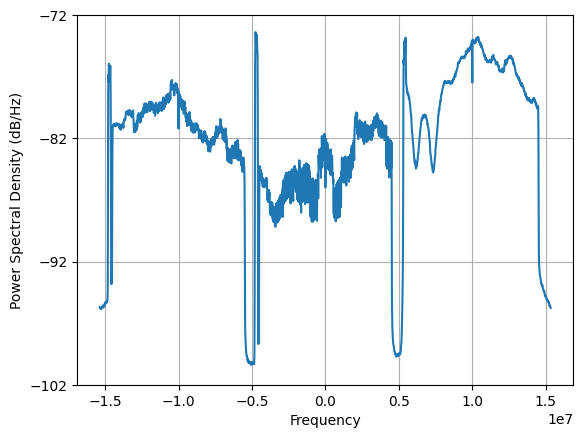

In [5]:
# First the PSD
Pxx, ff = plt.psd(rx[:], Fs=Fs, NFFT=2048)
plt.show()

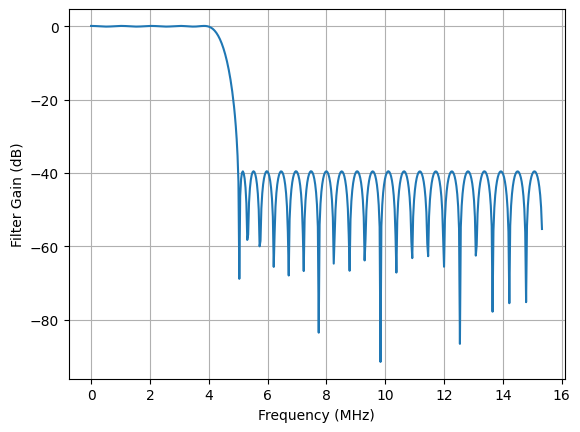

In [6]:
# design an FIR filter with (one-sided) bandwidth 4.5MHz
h = signal.remez(60, [0, 4e6, 5e6, Fs/2], [1, 0], fs=Fs)
w, H = signal.freqz(h, fs=Fs)

plt.plot(w/1e6, 20*np.log10(np.abs(H)))
plt.grid()

plt.xlabel('Frequency (MHz)')
plt.ylabel('Filter Gain (dB)')

plt.show()

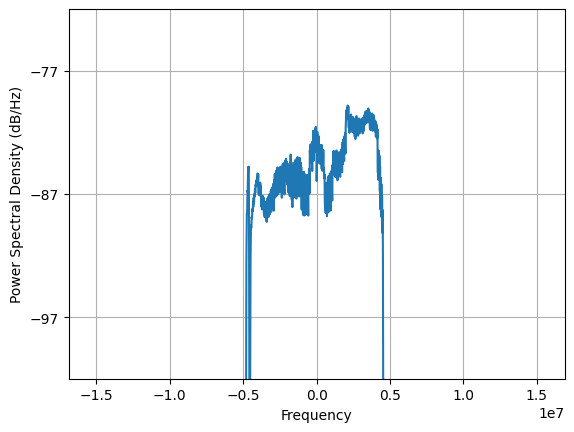

In [7]:
rx = np.convolve(rx, h)
Pxx, ff = plt.psd(rx, Fs=Fs, NFFT=2048)
plt.ylim(-102, -72)

plt.show()

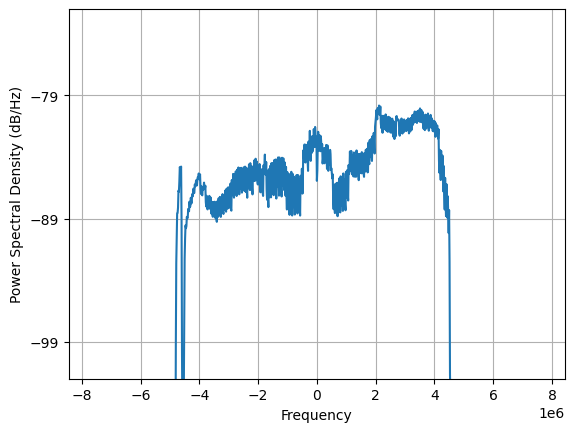

In [8]:
## Down-sample the signal by a factor of 2
rxf = rx[::2]
Fs = Fs/2

# system parameters
df_sc = 15e3                              # subcarrier spacing
N_FFT = int(Fs / df_sc)                   # FFT size: 1024
N_CP = 144 // (2048 // N_FFT)             # normal CP: 72
N_CP_extra = 16 // (2048 // N_FFT)        # extra CP for first symbol: 8
N_subframe = int(Fs * 1e-3)               # samples per subframe: 15360

# plot the spectrum again
Pxx, ff = plt.psd(rxf, Fs=Fs, NFFT=N_FFT)
plt.ylim(-102, -72)

plt.show()

In [9]:
import sys
sys.path.insert(0, '../include')
sys.path.insert(0, '../data')

from lte_system_info import LTEParams
from protected_circular_buffer import CircularBuffer
from cell_search import PSSDetection, SSSDetection, PSSChunk
from crs_estimate import CRSChannelEstimation
from mib_decode import PBCHDecoding, BCHDecoding, MIBChunk
from sib1_decode_control import PCFICHDecoding, PDCCHDecoding

# SIB1Chunk inline — all fields visible
class SIB1Chunk:
    def __init__(self, data, tag, N_id, N_rb, ns, f_d, n_ant,
                 phich_res, sfn, n_symbols=14, is_slot_start=True):
        N_sc = N_rb * 12
        self.data = data
        self.tag = tag
        self.N_id = N_id
        self.N_rb = N_rb
        self.N_sc = N_sc
        self.ns = ns
        self.f_d = f_d
        self.n_symbols = n_symbols
        self.is_slot_start = is_slot_start
        self.n_ant = n_ant
        self.phich_res = phich_res
        self.sfn = sfn
        self.symbols = np.zeros((n_symbols, N_sc), dtype=complex)
        self.H = np.zeros((4, n_symbols, N_sc), dtype=complex)
        self.cfi = None
        self.cfi_hamming = None
        self.dci_decoded = False
        self.dci_cost = None
        self.rb_start = None
        self.L_crbs = None
        self.Q_m = None
        self.rv = None
        self.tbs = None

In [10]:
Fs = float(np.load('../data/Fs.npy'))
params = LTEParams(Fs=Fs)

In [11]:
stride = params.stride

In [12]:
# Test: PSSDetection on real data 

buf = CircularBuffer(len(rxf))
buf.write(rxf)

pss = PSSDetection(params, peak_ratio=5.0)

pos = 0
chunk_id = 0
pss_count = 0

while pos + params.N_subframe <= len(rxf):
    pid = buf.protect(pos, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    chunk = pss(PSSChunk(data, chunk_id))

    if chunk.pss_detected:
        pss_count += 1
        global_pss = pos + chunk.pss_local_index
        print(f"Chunk {chunk_id}: PSS detected | "
              f"N_id_2={chunk.N_id_2}, "
              f"local={chunk.pss_local_index}, global={global_pss}")

    pos += stride
    chunk_id += 1

print(f"\nScanned {chunk_id} chunks over {len(rxf)} samples, "
      f"{pss_count} PSS detected")

Chunk 0: PSS detected | N_id_2=2, local=12309, global=12309
Chunk 2: PSS detected | N_id_2=2, local=9563, global=36043
Chunk 6: PSS detected | N_id_2=2, local=9667, global=89107
Chunk 8: PSS detected | N_id_2=2, local=6922, global=112842
Chunk 12: PSS detected | N_id_2=2, local=7027, global=165907
Chunk 13: PSS detected | N_id_2=0, local=11192, global=183312
Chunk 14: PSS detected | N_id_2=2, local=4283, global=189643
Chunk 18: PSS detected | N_id_2=2, local=4390, global=242710
Chunk 19: PSS detected | N_id_2=2, local=14327, global=265887
Chunk 20: PSS detected | N_id_2=2, local=1642, global=266442
Chunk 22: PSS detected | N_id_2=2, local=14330, global=305610
Chunk 24: PSS detected | N_id_2=2, local=1746, global=319506
Chunk 25: PSS detected | N_id_2=2, local=12243, global=343243
Chunk 26: PSS detected | N_id_2=1, local=2587, global=346827
Chunk 29: PSS detected | N_id_2=2, local=12349, global=396309
Chunk 31: PSS detected | N_id_2=2, local=9602, global=420042
Chunk 35: PSS detected | 

In [13]:
# Test: SSSDetection on real data 

buf = CircularBuffer(len(rxf))
buf.write(rxf)

pss = PSSDetection(params, peak_ratio=5.0)
sss = SSSDetection(params, peak_ratio=8.0)

pos = 0
chunk_id = 0
cells = []

while pos + params.N_subframe <= len(rxf):
    pid = buf.protect(pos, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    chunk = sss(pss(PSSChunk(data, chunk_id)))

    if chunk.pss_detected and chunk.sss_detected:
        N_id = 3 * chunk.N_id_1 + chunk.N_id_2
        global_pss = pos + chunk.pss_local_index
        cells.append({
            'tag': chunk_id, 'pos': pos,
            'N_id': N_id, 'N_id_1': chunk.N_id_1, 'N_id_2': chunk.N_id_2,
            'F': chunk.F, 'pss_local_index': chunk.pss_local_index,
            'f_d': chunk.f_d
        })
        print(f"Chunk {chunk_id}: PCI={N_id} | "
              f"N_id_1={chunk.N_id_1}, N_id_2={chunk.N_id_2}, "
              f"F={chunk.F}, local={chunk.pss_local_index}, global={global_pss} | "
              f"f_d={chunk.f_d:.1f} Hz")

    pos += stride
    chunk_id += 1

print(f"\nScanned {chunk_id} chunks, {len(cells)} cells found")

if cells:
    first_global = cells[0]['pos'] + cells[0]['pss_local_index']
    half_frame = params.N_half_frame
    expected = (len(rxf) - first_global) // half_frame + 1
    print(f"Expected {expected} cell found ({half_frame} spacing from {first_global})")

Chunk 2: PCI=380 | N_id_1=126, N_id_2=2, F=0, local=9563, global=36043 | f_d=1126.9 Hz
Chunk 8: PCI=380 | N_id_1=126, N_id_2=2, F=1, local=6922, global=112842 | f_d=1128.4 Hz
Chunk 14: PCI=380 | N_id_1=126, N_id_2=2, F=0, local=4283, global=189643 | f_d=1164.2 Hz
Chunk 20: PCI=380 | N_id_1=126, N_id_2=2, F=1, local=1642, global=266442 | f_d=1204.1 Hz
Chunk 25: PCI=380 | N_id_1=126, N_id_2=2, F=0, local=12243, global=343243 | f_d=1180.9 Hz
Chunk 31: PCI=380 | N_id_1=126, N_id_2=2, F=1, local=9602, global=420042 | f_d=1107.1 Hz
Chunk 37: PCI=380 | N_id_1=126, N_id_2=2, F=0, local=6962, global=496842 | f_d=1179.5 Hz
Chunk 43: PCI=380 | N_id_1=126, N_id_2=2, F=1, local=4323, global=573643 | f_d=1142.0 Hz
Chunk 49: PCI=380 | N_id_1=126, N_id_2=2, F=0, local=1681, global=650441 | f_d=1269.2 Hz
Chunk 54: PCI=380 | N_id_1=126, N_id_2=2, F=1, local=12282, global=727242 | f_d=1165.1 Hz
Chunk 60: PCI=380 | N_id_1=126, N_id_2=2, F=0, local=9642, global=804042 | f_d=1122.2 Hz
Chunk 66: PCI=380 | N_

In [14]:
# MIB decode for even-numbered cells (F=0)

crs_mib = CRSChannelEstimation(params)
crs_mib.config(N_id=cells[0]['N_id'], N_rb=6, ns=1, n_symbols=4, is_slot_start=True)

pbch = PBCHDecoding()
pbch.config(N_id=cells[0]['N_id'])

bch = BCHDecoding()
bch.config(N_id=cells[0]['N_id'])

for n in range(0, len(cells), 2):

    cell = cells[n]
    N_id = cell['N_id']
    F = cell['F']
    f_d = cell['f_d']
    first_pss_global = cell['pos'] + cell['pss_local_index']

    print("=" * 50)
    print(f"Cell #{n}: PCI={N_id}, F={F}, f_d={f_d:.1f} Hz")
    print(f"PSS global at: {first_pss_global}")

    # locate PBCH
    slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame
    pbch_len = params.pbch_len

    pid = buf.protect(slot1_start, pbch_len)
    data = buf.read_protected(pid)
    buf.release(pid)

    chunk = MIBChunk(data, tag=n, N_id=N_id, f_d=f_d)
    crs_mib(chunk)

    # blind antenna trial
    for n_ant in [1, 2, 4]:
        chunk.n_ant = n_ant
        pbch(chunk)
        bch(chunk)

        if chunk.mib_decoded:
            print(f"  Result:       MIB decoded (n_ant={n_ant})")
            print(f"  DL Bandwidth: {chunk.dl_bw} RBs")
            print(f"  PHICH dur:    {chunk.phich_dur}")
            print(f"  PHICH res:    {chunk.phich_res}")
            print(f"  SFN:          {chunk.sfn}")
            print(f"  Segment:      {chunk.sec}")
            break

    if not chunk.mib_decoded:
        print(f"  Result:       FAILED")

print("=" * 50)

Cell #0: PCI=380, F=0, f_d=1126.9 Hz
PSS global at: 36043
  Result:       MIB decoded (n_ant=2)
  DL Bandwidth: 50 RBs
  PHICH dur:    normal
  PHICH res:    1
  SFN:          313
  Segment:      1
Cell #2: PCI=380, F=0, f_d=1164.2 Hz
PSS global at: 189643
  Result:       MIB decoded (n_ant=2)
  DL Bandwidth: 50 RBs
  PHICH dur:    normal
  PHICH res:    1
  SFN:          314
  Segment:      2
Cell #4: PCI=380, F=0, f_d=1180.9 Hz
PSS global at: 343243
  Result:       MIB decoded (n_ant=2)
  DL Bandwidth: 50 RBs
  PHICH dur:    normal
  PHICH res:    1
  SFN:          315
  Segment:      3
Cell #6: PCI=380, F=0, f_d=1179.5 Hz
PSS global at: 496842
  Result:       MIB decoded (n_ant=2)
  DL Bandwidth: 50 RBs
  PHICH dur:    normal
  PHICH res:    1
  SFN:          316
  Segment:      0
Cell #8: PCI=380, F=0, f_d=1269.2 Hz
PSS global at: 650441
  Result:       MIB decoded (n_ant=2)
  DL Bandwidth: 50 RBs
  PHICH dur:    normal
  PHICH res:    1
  SFN:          317
  Segment:      1
Cell #

In [15]:
# Fast check CFI across all SIB1-eligible subframes

crs_sib = CRSChannelEstimation(params)
pcfich = PCFICHDecoding()
N_id = cells[0]['N_id']

print("fast check CFI across all SIB1-eligible subframes...\n")

for n in range(0, len(cells), 2):
    cell = cells[n]
    F = cell['F']
    f_d = cell['f_d']
    first_pss_global = cell['pos'] + cell['pss_local_index']

    slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

    # MIB decode (quick)
    pid = buf.protect(slot1_start, params.pbch_len)
    data = buf.read_protected(pid)
    buf.release(pid)

    mib_chunk = MIBChunk(data, tag=n, N_id=N_id, f_d=f_d)
    crs_mib(mib_chunk)
    for n_ant in [1, 2, 4]:
        mib_chunk.n_ant = n_ant
        pbch(mib_chunk)
        bch(mib_chunk)
        if mib_chunk.mib_decoded:
            break
    if not mib_chunk.mib_decoded or mib_chunk.sfn % 2 != 0:
        continue

    # locate subframe 5
    frame_start = slot1_start - params.N_slot
    subf5_start = frame_start + 5 * params.N_subframe

    pid = buf.protect(subf5_start, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    sib_chunk = SIB1Chunk(data, tag=n, N_id=N_id, N_rb=mib_chunk.dl_bw,
                          ns=10, f_d=f_d, n_ant=mib_chunk.n_ant,
                          phich_res=mib_chunk.phich_res, sfn=mib_chunk.sfn)

    crs_sib.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10, n_symbols=14, is_slot_start=True)
    crs_sib(sib_chunk)

    pcfich.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10)
    pcfich(sib_chunk)

    print(f"cells[{n:3d}] SFN={mib_chunk.sfn} CFI={sib_chunk.cfi} hamming={sib_chunk.cfi_hamming}")

fast check CFI across all SIB1-eligible subframes...

cells[  2] SFN=314 CFI=1 hamming=0
cells[  6] SFN=316 CFI=1 hamming=0
cells[ 10] SFN=318 CFI=1 hamming=0
cells[ 14] SFN=320 CFI=1 hamming=0
cells[ 18] SFN=322 CFI=1 hamming=0
cells[ 22] SFN=324 CFI=1 hamming=0
cells[ 26] SFN=326 CFI=2 hamming=0
cells[ 30] SFN=328 CFI=2 hamming=0
cells[ 34] SFN=330 CFI=2 hamming=0
cells[ 38] SFN=332 CFI=2 hamming=0
cells[ 42] SFN=334 CFI=2 hamming=0
cells[ 46] SFN=336 CFI=2 hamming=0
cells[ 50] SFN=338 CFI=2 hamming=0
cells[ 54] SFN=340 CFI=2 hamming=0
cells[ 58] SFN=342 CFI=2 hamming=0
cells[ 62] SFN=344 CFI=2 hamming=0
cells[ 66] SFN=346 CFI=2 hamming=0
cells[ 70] SFN=348 CFI=2 hamming=0
cells[ 74] SFN=350 CFI=2 hamming=0
cells[ 78] SFN=352 CFI=2 hamming=0
cells[ 82] SFN=354 CFI=2 hamming=0
cells[ 86] SFN=356 CFI=1 hamming=1
cells[ 90] SFN=358 CFI=1 hamming=2
cells[ 94] SFN=360 CFI=1 hamming=0
cells[ 98] SFN=362 CFI=1 hamming=0
cells[102] SFN=364 CFI=1 hamming=0
cells[106] SFN=366 CFI=2 hamming=2
c

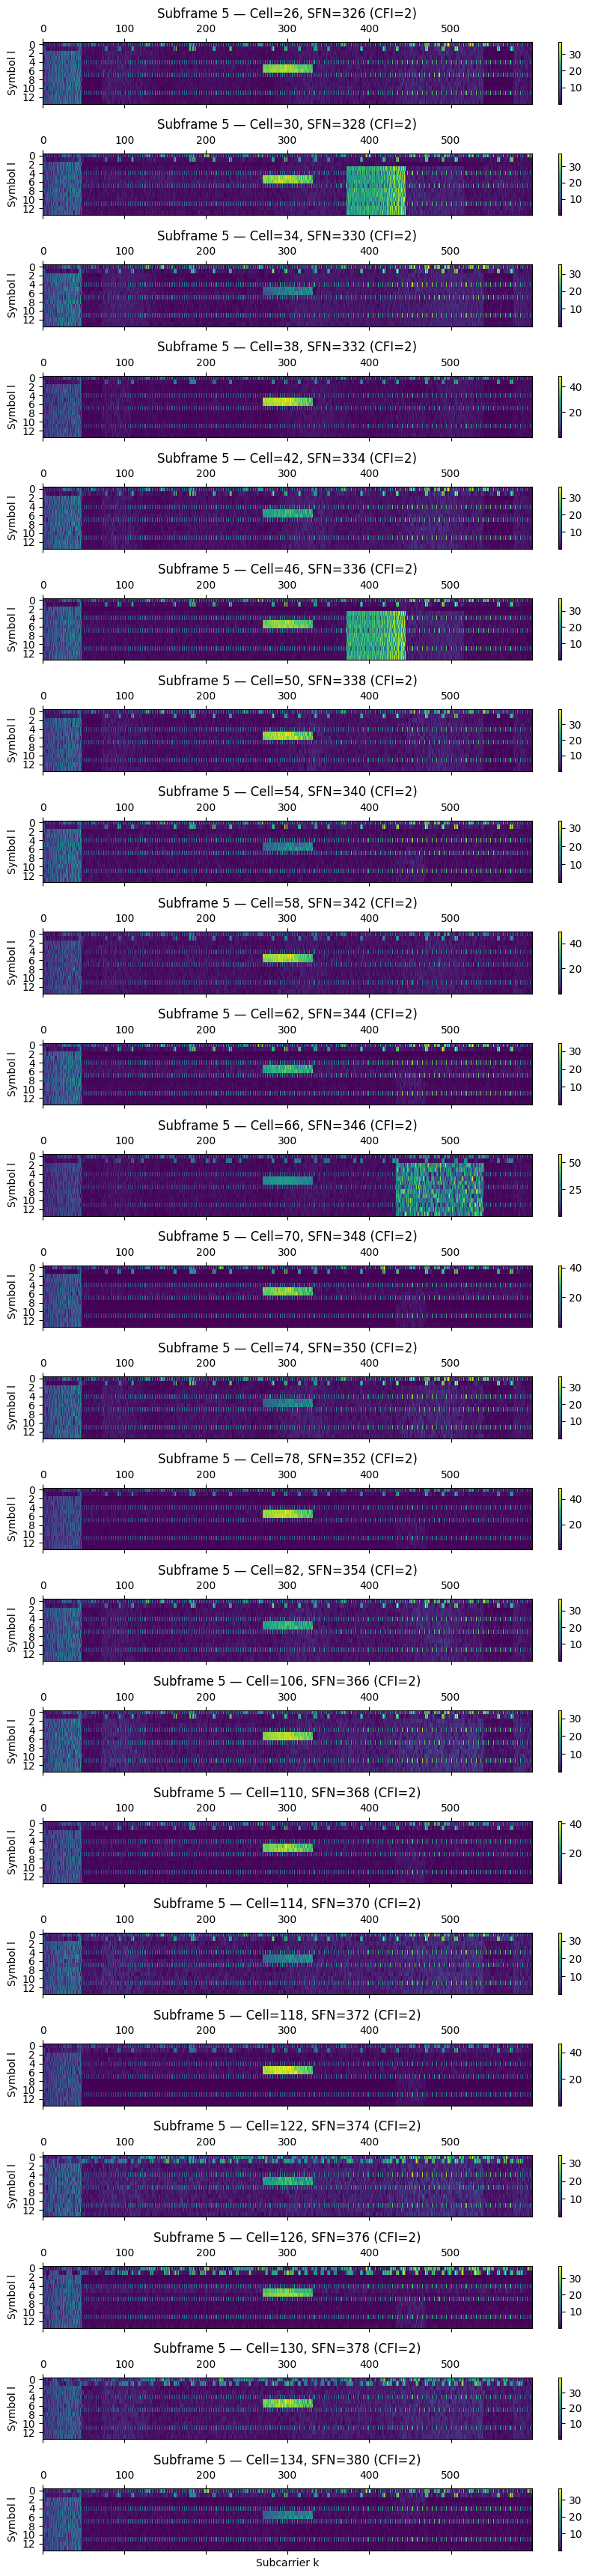


Total CFI=2 cases: 23


In [16]:
# Plot subframe 5 resource grid for all CFI=2 cases

cfi2_symbols = []
cfi2_sfns = []
cell_n = []

for n in range(2, len(cells), 4):
    cell = cells[n]
    N_id = cell['N_id']
    F = cell['F']
    f_d = cell['f_d']
    first_pss_global = cell['pos'] + cell['pss_local_index']

    # MIB
    slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

    pid = buf.protect(slot1_start, params.pbch_len)
    data = buf.read_protected(pid)
    buf.release(pid)

    mib_chunk = MIBChunk(data, tag=0, N_id=N_id, f_d=f_d)
    crs_mib(mib_chunk)

    for n_ant in [1, 2, 4]:
        mib_chunk.n_ant = n_ant
        pbch(mib_chunk)
        bch(mib_chunk)
        if mib_chunk.mib_decoded:
            break

    if not mib_chunk.mib_decoded:
        continue

    # locate subframe 5
    frame_start = slot1_start - params.N_slot
    subf5_start = frame_start + 5 * params.N_subframe

    pid = buf.protect(subf5_start, params.N_subframe)
    data = buf.read_protected(pid)
    buf.release(pid)

    sib_chunk = SIB1Chunk(data, tag=0, N_id=N_id, N_rb=mib_chunk.dl_bw,
                          ns=10, f_d=f_d, n_ant=mib_chunk.n_ant,
                          phich_res=mib_chunk.phich_res, sfn=mib_chunk.sfn)

    crs_sib.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10, n_symbols=14, is_slot_start=True)
    crs_sib(sib_chunk)

    pcfich.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10)
    pcfich(sib_chunk)

    if sib_chunk.cfi == 2:
        cfi2_symbols.append(np.abs(sib_chunk.symbols))
        cfi2_sfns.append(mib_chunk.sfn)
        cell_n.append(n)

# Plot all CFI=2 cases
n_plots = len(cfi2_symbols)
fig, axes = plt.subplots(n_plots, 1, figsize=(8, 1.5 * n_plots))

if n_plots == 1:
    axes = [axes]

for i, (n, sym, sfn) in enumerate(zip(cell_n, cfi2_symbols, cfi2_sfns)):
    im = axes[i].matshow(sym, aspect='auto')
    axes[i].set_ylabel('Symbol l')
    axes[i].set_title(f'Subframe 5 — Cell={n}, SFN={sfn} (CFI=2)')
    fig.colorbar(im, ax=axes[i], fraction=0.02)

axes[-1].set_xlabel('Subcarrier k')
plt.tight_layout()
plt.show()

print(f"\nTotal CFI=2 cases: {n_plots}")

In [17]:
# Test: PCFICH Decoding for CFI=1 case

cell = cells[2]
N_id = cell['N_id']
F = cell['F']
f_d = cell['f_d']
first_pss_global = cell['pos'] + cell['pss_local_index']
print(f"Cell: PCI={N_id}, F={F}, f_d={f_d:.1f} Hz")

# MIB
slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

pid = buf.protect(slot1_start, params.pbch_len)
data = buf.read_protected(pid)
buf.release(pid)

mib_chunk = MIBChunk(data, tag=0, N_id=N_id, f_d=f_d)
crs_mib(mib_chunk)
for n_ant in [1, 2, 4]:
    mib_chunk.n_ant = n_ant
    pbch(mib_chunk)
    bch(mib_chunk)
    if mib_chunk.mib_decoded:
        break

assert mib_chunk.mib_decoded, "MIB decoding failed"
print(f"MIB: BW={mib_chunk.dl_bw} RBs, n_ant={mib_chunk.n_ant}, "
      f"SFN={mib_chunk.sfn}, PHICH_res={mib_chunk.phich_res}")

# Locate subframe 5
frame_start = slot1_start - params.N_slot
subf5_start = frame_start + 5 * params.N_subframe

print(f"\nFrame start: sample {frame_start}")
print(f"Subframe 5 start: sample {subf5_start}")
print(f"SFN={mib_chunk.sfn}, even={mib_chunk.sfn % 2 == 0}")

# SIB1 chunk + CRS + PCFICH
pid = buf.protect(subf5_start, params.N_subframe)
data = buf.read_protected(pid)
buf.release(pid)

sib_chunk = SIB1Chunk(data, tag=0, N_id=N_id, N_rb=mib_chunk.dl_bw,
                      ns=10, f_d=f_d, n_ant=mib_chunk.n_ant,
                      phich_res=mib_chunk.phich_res, sfn=mib_chunk.sfn)

crs_sib.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10, n_symbols=14, is_slot_start=True)
crs_sib(sib_chunk)

pcfich.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10)
pcfich(sib_chunk)

print(f"\n=== PCFICH Decoded ===")
print(f"  CFI:              {sib_chunk.cfi}")
print(f"  Hamming distance: {sib_chunk.cfi_hamming}")
print(f"  Control region:   {sib_chunk.cfi} OFDM symbol(s)")
print(f"  Data region:      symbols {sib_chunk.cfi} to 13")

Cell: PCI=380, F=0, f_d=1164.2 Hz
MIB: BW=50 RBs, n_ant=2, SFN=314, PHICH_res=1

Frame start: sample 182987
Subframe 5 start: sample 259787
SFN=314, even=True

=== PCFICH Decoded ===
  CFI:              1
  Hamming distance: 0
  Control region:   1 OFDM symbol(s)
  Data region:      symbols 1 to 13


### CFI = 1

In [22]:
## Figure out which REGs are used by PCFICH, PHICH, and what is left
# start with all REGs
all_REG = {n for n in range(2*sib_chunk.N_rb)}

# PCFICH REGs
PCFI_REG = {(N_id % (2*sib_chunk.N_rb) + (n*sib_chunk.N_rb) // 2) % (2*sib_chunk.N_rb) for n in range(4)}

# this is what's left for PHICH and PDCCH
all_REG.difference_update(PCFI_REG)
all_REG_vec = np.sort(np.array([n for n in all_REG]))
n_0 = len(all_REG)

# now deal with the PHICH
PHICH_REG = set()

# note: this is specific to FDD and normal CP
Ng = 1   # this reflects phich-Resource from MIB
N_group = (Ng * sib_chunk.N_rb) // 8
if 8*N_group < Ng * sib_chunk.N_rb:
    N_group += 1

for m in range(N_group):
    for i in range(3):
        n_i = (N_id + m + ((i*n_0) // 3)) % n_0
        reg = all_REG_vec[n_i]
        all_REG.discard(reg)
        PHICH_REG.add(reg)
        
print("After PCFICH and PHICH, there are {:d} REGs left for the PDCCH".format(len(all_REG)))
print("all_REG = ",all_REG)

After PCFICH and PHICH, there are 75 REGs left for the PDCCH
all_REG =  {3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95}


In [24]:
# PDCCH REG extraction — reads from sib_chunk.symbols and sib_chunk.H
from mib_decode import equalize_2ant

pdcch_reg = np.array(sorted(all_REG))
N_reg = len(pdcch_reg)

# de-cyclic shift
pdcch_reg_cs = np.roll(pdcch_reg,(N_id%N_reg))

# de-interleaving
from mib_decode import subblock_interleaver
perm_table = subblock_interleaver(N_reg)

pdcch_num_reg = np.zeros(N_reg, dtype=np.int64)
pdcch_num_reg[perm_table] = pdcch_reg_cs

# CRS-aware data offsets
nu_shift = N_id % 6
crs_positions = {nu_shift, (3 + nu_shift) % 6}
data_offsets = [i for i in range(6) if i not in crs_positions]

r_pdcch = np.zeros(N_reg * 4, dtype=complex)
H_pdcch = np.zeros((4, N_reg * 4), dtype=complex)

for i, reg in enumerate(pdcch_num_reg):
    for j, off in enumerate(data_offsets):
        k = 6 * reg + off
        idx = i * 4 + j
        r_pdcch[idx] = sib_chunk.symbols[0, k]
        H_pdcch[:, idx] = sib_chunk.H[:, 0, k]

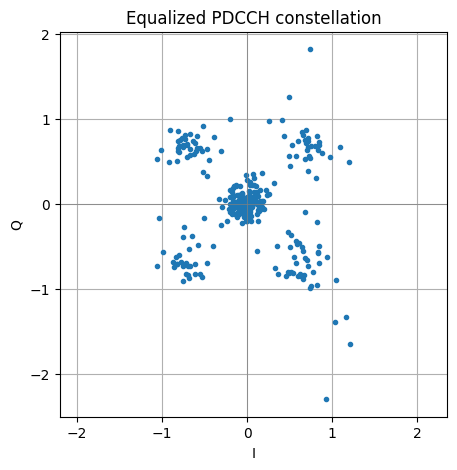

In [25]:
# --- Equalize (2-antenna SFBC) ---
x_pdcch = equalize_2ant(r_pdcch, H_pdcch)

# --- Quick sanity check: constellation should look like QPSK ---
plt.figure(figsize=(5, 5))
plt.plot(x_pdcch.real, x_pdcch.imag, '.')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.grid(True)
plt.axis('equal')
plt.xlabel('I')
plt.ylabel('Q')
plt.title('Equalized PDCCH constellation')
plt.show()

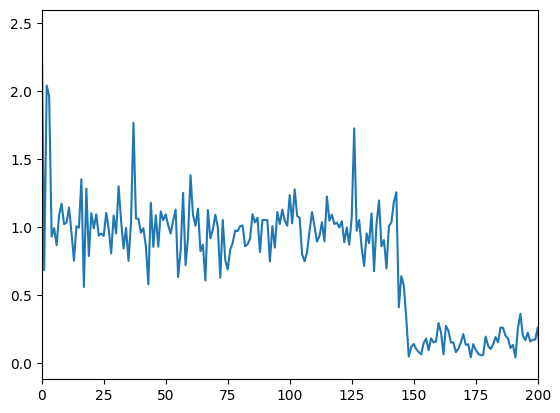

In [26]:
plt.plot(np.abs(x_pdcch))
plt.xlim(0,200)
plt.show()

In [27]:
# --- QPSK demod ---
pdcch_scrambled_bits = np.zeros(N_reg * 8, dtype=np.uint8)
pdcch_scrambled_bits[0::2] = (x_pdcch.real < 0).astype(np.uint8)
pdcch_scrambled_bits[1::2] = (x_pdcch.imag < 0).astype(np.uint8)

In [28]:
# --- Descramble (TS 36.211 sec 6.8.2) ---
from crs_estimate import c_sequence

ns = sib_chunk.ns  # should be 10 for subframe 5
c_init = ((ns // 2) << 9) + N_id
c = c_sequence(len(pdcch_scrambled_bits), c_init)
pdcch_bits = pdcch_scrambled_bits ^ c

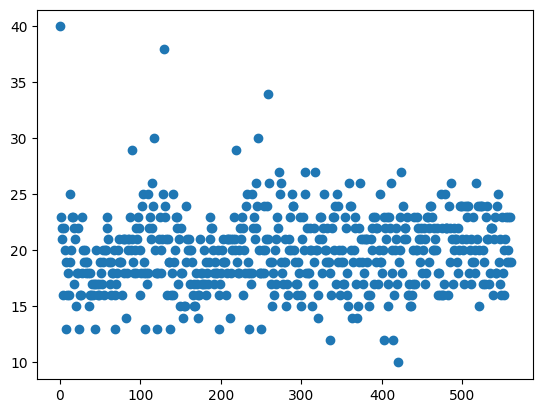

len of pdcch after multiplexing: 600


In [29]:
# look at correlations for different portion of pdcch bits.

wl = 40 # window size 
pdcch_f = pdcch_bits[:wl]
corr = []

win = 0
while win <= len(pdcch_bits)-wl:
    corr.append(wl-np.sum(pdcch_f ^ pdcch_bits[win:win+wl])) 
    win += 1
    
plt.plot(corr,'o')
plt.show()
print('len of pdcch after multiplexing:',len(pdcch_bits))

In [30]:
pdcch_f = pdcch_bits[:40]

best_n = 0
best_dist = 40
for n in range(1, len(pdcch_bits) - 40):
    dist = np.sum(pdcch_f != pdcch_bits[n:n+40])
    if dist < best_dist:
        best_dist = dist
        best_n = n

dci_len_3x = best_n
print(f'DCI length x3 = {dci_len_3x}, Hamming distance = {best_dist}')
print(f'DCI length = {dci_len_3x // 3}')

DCI length x3 = 129, Hamming distance = 2
DCI length = 43


In [32]:
# construct the permutation table
l_dci = dci_len_3x // 3

perm_table = subblock_interleaver(l_dci)

In [33]:
pdcch_coded_bits = np.zeros((3,l_dci),dtype=np.uint8)

for n in range(3):
    pdcch_coded_bits[n,perm_table] = pdcch_bits[n*l_dci:(n+1)*l_dci]

In [34]:
from mib_decode import ConvCoderNumba

fec = ConvCoderNumba([0o133, 0o171, 0o165])

In [35]:
pdcch_hard_bits, cost = fec.decode(pdcch_coded_bits)

print("cost = {:f}, bits = {:}".format(cost, pdcch_hard_bits))

cost = 2.000000, bits = [1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1
 1 1 0 1 0 1]


In [36]:
from mib_decode import CRC16

crc = CRC16()

In [37]:
n_dci = l_dci-16

dci_bits = pdcch_hard_bits[:n_dci]
parity_bits = pdcch_hard_bits[n_dci:] ^ 1

pdcch_crc_bits = np.concatenate([dci_bits,parity_bits])

crc_match = False

bytes = np.packbits(pdcch_crc_bits)

if crc(bytes) == 0:
    crc_match = True

assert crc_match == True

In [38]:
print('bits of dci: {:}, size: {:d}'.format(dci_bits,dci_bits.size))

bits of dci: [1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0], size: 27


1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0

### CFI = 2

In [39]:
# Test: PCFICH Decoding for CFI=2 case

cell = cells[30]
N_id = cell['N_id']
F = cell['F']
f_d = cell['f_d']
first_pss_global = cell['pos'] + cell['pss_local_index']
print(f"Cell: PCI={N_id}, F={F}, f_d={f_d:.1f} Hz")

# MIB
slot1_start = first_pss_global + params.N_FFT - F * params.N_half_frame

pid = buf.protect(slot1_start, params.pbch_len)
data = buf.read_protected(pid)
buf.release(pid)

mib_chunk = MIBChunk(data, tag=0, N_id=N_id, f_d=f_d)
crs_mib(mib_chunk)
for n_ant in [1, 2, 4]:
    mib_chunk.n_ant = n_ant
    pbch(mib_chunk)
    bch(mib_chunk)
    if mib_chunk.mib_decoded:
        break

assert mib_chunk.mib_decoded, "MIB decoding failed"
print(f"MIB: BW={mib_chunk.dl_bw} RBs, n_ant={mib_chunk.n_ant}, "
      f"SFN={mib_chunk.sfn}, PHICH_res={mib_chunk.phich_res}")

# Locate subframe 5
frame_start = slot1_start - params.N_slot
subf5_start = frame_start + 5 * params.N_subframe

# SIB1 chunk + CRS + PCFICH
pid = buf.protect(subf5_start, params.N_subframe)
data = buf.read_protected(pid)
buf.release(pid)

sib_chunk = SIB1Chunk(data, tag=0, N_id=N_id, N_rb=mib_chunk.dl_bw,
                      ns=10, f_d=f_d, n_ant=mib_chunk.n_ant,
                      phich_res=mib_chunk.phich_res, sfn=mib_chunk.sfn)

crs_sib.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10, n_symbols=14, is_slot_start=True)
crs_sib(sib_chunk)

pcfich.config(N_id=N_id, N_rb=mib_chunk.dl_bw, ns=10)
pcfich(sib_chunk)

print(f"\n=== PCFICH Decoded ===")
print(f"  CFI:              {sib_chunk.cfi}")
print(f"  Hamming distance: {sib_chunk.cfi_hamming}")

Cell: PCI=380, F=0, f_d=1044.2 Hz
MIB: BW=50 RBs, n_ant=2, SFN=328, PHICH_res=1

=== PCFICH Decoded ===
  CFI:              2
  Hamming distance: 0


In [40]:
## Figure out which REGs are used by PCFICH, PHICH, and what is left
all_REG = {n for n in range(2 * sib_chunk.N_rb)}

PCFI_REG = {(N_id % (2*sib_chunk.N_rb) + (n*sib_chunk.N_rb) // 2) % (2*sib_chunk.N_rb) for n in range(4)}

all_REG.difference_update(PCFI_REG)
all_REG_vec = np.sort(np.array([n for n in all_REG]))
n_0 = len(all_REG)

PHICH_REG = set()

Ng = 1
N_group = (Ng * sib_chunk.N_rb) // 8
if 8 * N_group < Ng * sib_chunk.N_rb:
    N_group += 1

for m in range(N_group):
    for i in range(3):
        n_i = (N_id + m + ((i * n_0) // 3)) % n_0
        reg = all_REG_vec[n_i]
        all_REG.discard(reg)
        PHICH_REG.add(reg)

print("After PCFICH and PHICH, there are {:d} REGs left for the PDCCH in symbol 0".format(len(all_REG)))

# --- Build combined REG table: symbol 0 + symbol 1 ---
nu_shift = N_id % 6
crs_positions = {nu_shift, (3 + nu_shift) % 6}
data_offsets = [i for i in range(6) if i not in crs_positions]

reg_table = []

for reg_idx in sorted(all_REG):
    k_start = 6 * reg_idx
    reg_table.append((k_start, 0, [k_start + off for off in data_offsets]))

for reg_idx in range(3 * sib_chunk.N_rb):
    k_start = 4 * reg_idx
    reg_table.append((k_start, 1, [k_start, k_start+1, k_start+2, k_start+3]))

reg_table.sort(key=lambda x: (x[0], x[1]))

N_reg = len(reg_table)
print("Total: {:d} REGs, {:d} CCEs, {:d} leftover".format(N_reg, N_reg // 9, N_reg % 9))

After PCFICH and PHICH, there are 75 REGs left for the PDCCH in symbol 0
Total: 225 REGs, 25 CCEs, 0 leftover


In [42]:
# de-cyclic shift
pdcch_reg = np.arange(N_reg)
pdcch_reg_cs = np.roll(pdcch_reg, N_id % N_reg)

# de-interleaving
perm_table = subblock_interleaver(N_reg)

pdcch_num_reg = np.zeros(N_reg, dtype=np.int64)
pdcch_num_reg[perm_table] = pdcch_reg_cs

# --- Extract 4 REs per REG from sib_chunk ---
r_pdcch = np.zeros(N_reg * 4, dtype=complex)
H_pdcch = np.zeros((4, N_reg * 4), dtype=complex)

for i, reg in enumerate(pdcch_num_reg):
    sym_l, k_list = reg_table[reg][1], reg_table[reg][2]
    for j, k in enumerate(k_list):
        idx = i * 4 + j
        r_pdcch[idx] = sib_chunk.symbols[sym_l, k]
        H_pdcch[:, idx] = sib_chunk.H[:, sym_l, k]

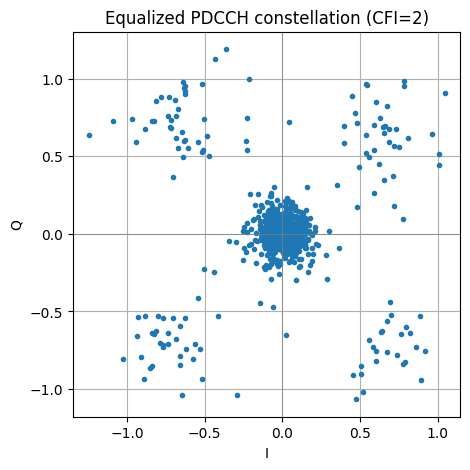

In [43]:
# --- Equalize (2-antenna SFBC) ---
x_pdcch = equalize_2ant(r_pdcch, H_pdcch)

plt.figure(figsize=(5, 5))
plt.plot(x_pdcch.real, x_pdcch.imag, '.')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.grid(True)
plt.axis('equal')
plt.xlabel('I')
plt.ylabel('Q')
plt.title('Equalized PDCCH constellation (CFI=2)')
plt.show()

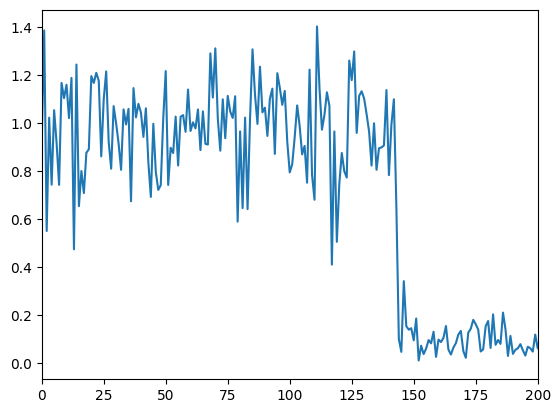

In [44]:
plt.plot(np.abs(x_pdcch))
plt.xlim(0,200)
plt.show()

In [45]:
# --- QPSK demod ---
pdcch_scrambled_bits = np.zeros(N_reg * 8, dtype=np.uint8)
pdcch_scrambled_bits[0::2] = (x_pdcch.real < 0).astype(np.uint8)
pdcch_scrambled_bits[1::2] = (x_pdcch.imag < 0).astype(np.uint8)

In [46]:
# --- Descramble ---
ns = sib_chunk.ns
c_init = ((ns // 2) << 9) + N_id
c = c_sequence(len(pdcch_scrambled_bits), c_init)
pdcch_bits = pdcch_scrambled_bits ^ c

In [48]:
# construct the permutation table
l_dci = 43

perm_table = subblock_interleaver(l_dci)

In [49]:
pdcch_coded_bits = np.zeros((3,l_dci),dtype=np.uint8)

for n in range(3):
    pdcch_coded_bits[n,perm_table] = pdcch_bits[n*l_dci:(n+1)*l_dci]

In [50]:
fec = ConvCoderNumba([0o133, 0o171, 0o165])

In [51]:
pdcch_hard_bits, cost = fec.decode(pdcch_coded_bits)

print("cost = {:f}, bits = {:}".format(cost, pdcch_hard_bits))

cost = 0.000000, bits = [1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1
 0 0 0 1 0 0]


In [52]:
crc = CRC16()

In [53]:
n_dci = l_dci-16

dci_bits = pdcch_hard_bits[:n_dci]
parity_bits = pdcch_hard_bits[n_dci:] ^ 1

pdcch_crc_bits = np.concatenate([dci_bits,parity_bits])

crc_match = False

bytes = np.packbits(pdcch_crc_bits)

if crc(bytes) == 0:
    crc_match = True

assert crc_match == True

In [54]:
print('bits of dci: {:}, size: {:d}'.format(dci_bits,dci_bits.size))

bits of dci: [1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0], size: 27


1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 <br>
1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0